In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/train (2).csv")

In [4]:
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [5]:
df.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
id,0
health_condition,0
sleep_duration,75999
heart_rate,7833
bmi,13898
calorie_expenditure,52853
step_count,13916
exercise_duration,6901
water_intake,43477
diet_type,6901


In [7]:
num_cols = ['sleep_duration','heart_rate','bmi',
            'calorie_expenditure','step_count',
            'exercise_duration','water_intake']

In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
df[num_cols] = imputer.fit_transform(df[num_cols])

In [9]:
cat_cols = ['gender','diet_type',
            'smoking_alcohol',
            'physical_activity_level',
            'sleep_quality',
            'stress_level']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_8669/1013367294.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [10]:
df['gender'].fillna('Unknown', inplace=True)

In [11]:
df['stress_level_missing'] = df['stress_level'].isnull().astype(int)

In [12]:
df.isnull().sum()

,0
id,0
health_condition,0
sleep_duration,0
heart_rate,0
bmi,0
calorie_expenditure,0
step_count,0
exercise_duration,0
water_intake,0
diet_type,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,stress_level_missing
count,690088.00000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.0
mean,345043.50000,6.992311,75.096544,22.985027,2227.227258,8620.793728,38.757941,2.187374,0.0
std,199211.39062,1.146529,8.128577,2.456669,333.982029,3889.725112,14.668434,0.501911,0.0
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000,0.0
25%,172521.75000,6.300000,69.500000,21.380000,2068.000000,5460.000000,29.300000,1.870000,0.0
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000,0.0
75%,517565.25000,7.680000,80.600000,24.630000,2438.000000,12089.000000,49.300000,2.470000,0.0
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000,0.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           690088 non-null  float64
 3   heart_rate               690088 non-null  float64
 4   bmi                      690088 non-null  float64
 5   calorie_expenditure      690088 non-null  float64
 6   step_count               690088 non-null  float64
 7   exercise_duration        690088 non-null  float64
 8   water_intake             690088 non-null  float64
 9   diet_type                690088 non-null  object 
 10  stress_level             690088 non-null  object 
 11  sleep_quality            690088 non-null  object 
 12  physical_activity_level  690088 non-null  object 
 13  smoking_alcohol          690088 non-null  object 
 14  gend

In [16]:
df.shape

(690088, 16)

In [17]:
df.drop("id",axis=1,inplace=True)

<Axes: >

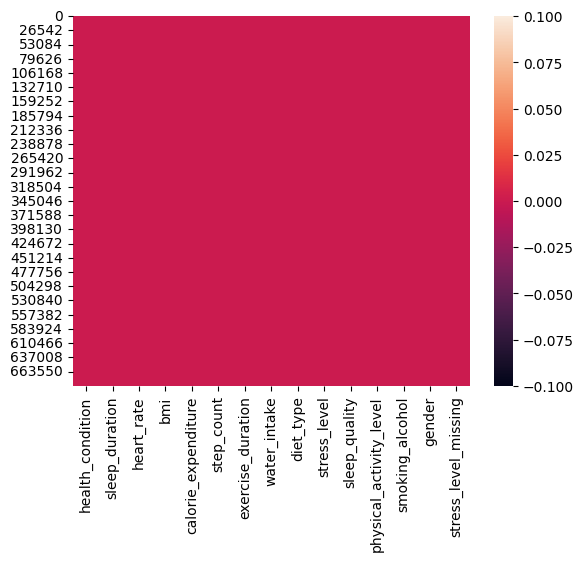

In [18]:
sns.heatmap(df.isnull())

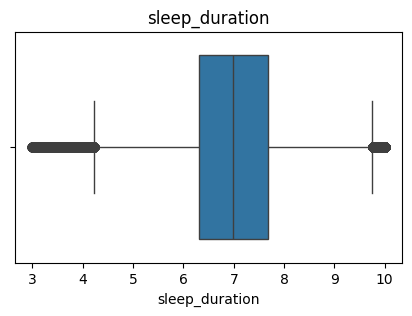

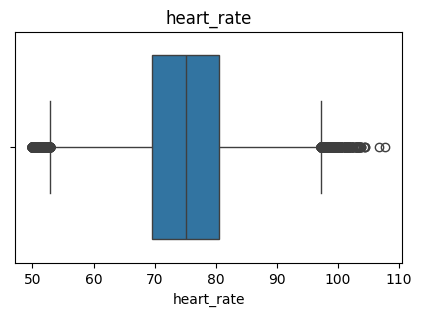

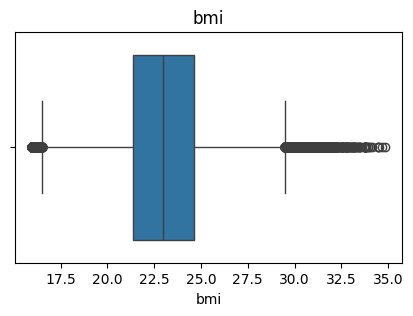

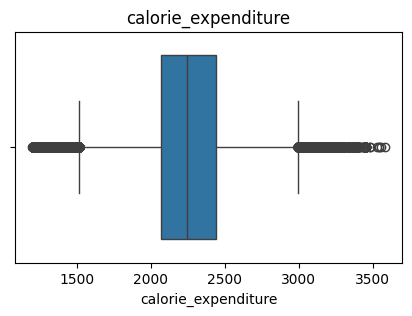

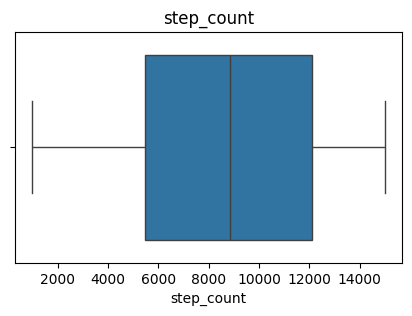

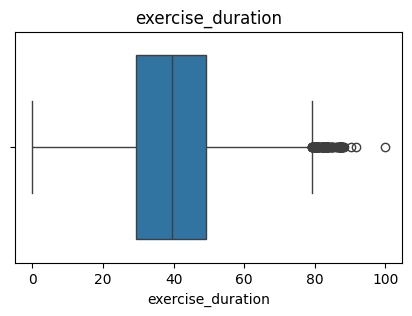

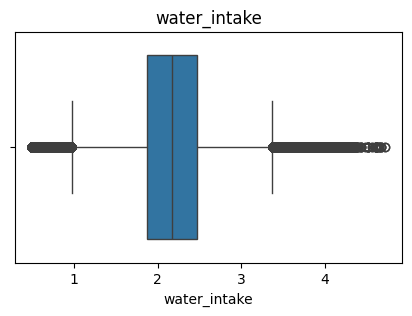

In [19]:
for i in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

In [20]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower_bound, upper_bound)
    print(f"Capping applied to '{col}'. Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

print("\nAll numerical columns have been capped for outliers.")


Capping applied to 'sleep_duration'. Lower bound: 4.23, Upper bound: 9.75
Capping applied to 'heart_rate'. Lower bound: 52.85, Upper bound: 97.25
Capping applied to 'bmi'. Lower bound: 16.50, Upper bound: 29.50
Capping applied to 'calorie_expenditure'. Lower bound: 1513.00, Upper bound: 2993.00
Capping applied to 'step_count'. Lower bound: -4483.50, Upper bound: 22032.50
Capping applied to 'exercise_duration'. Lower bound: -0.70, Upper bound: 79.30
Capping applied to 'water_intake'. Lower bound: 0.97, Upper bound: 3.37

All numerical columns have been capped for outliers.


In [21]:
display(df.head())

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,stress_level_missing
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,medium,average,sedentary,yes,male,0


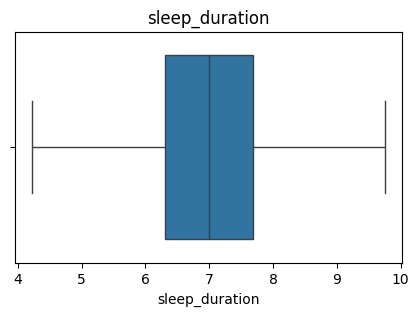

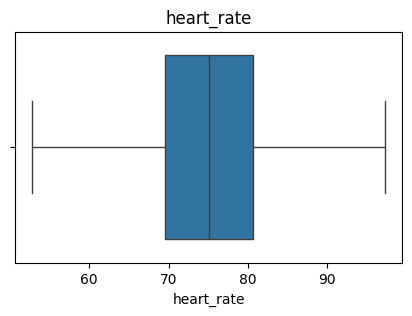

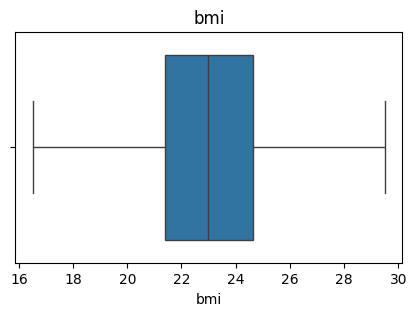

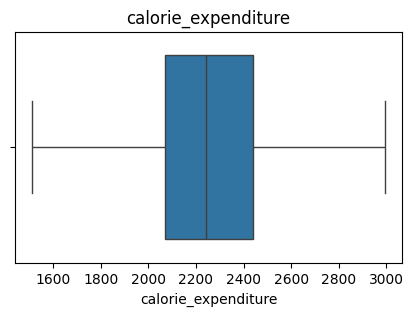

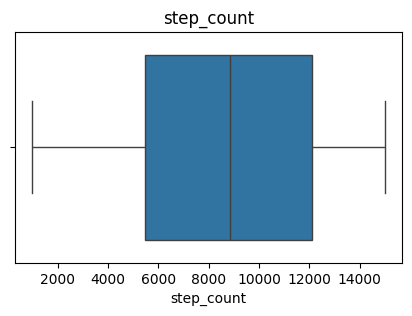

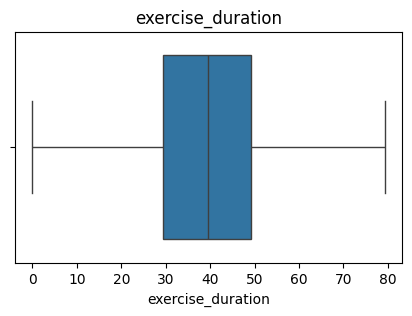

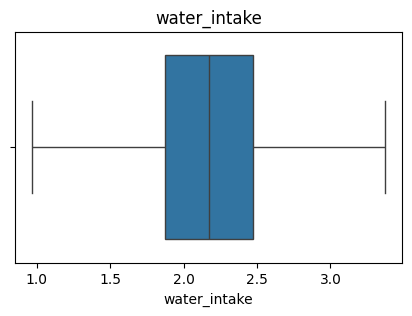

In [22]:
for j in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[j])
    plt.title(j)
    plt.show()

In [23]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for c in cat_cols:
    df[c]=le.fit_transform(df[c])

In [24]:
scaler=StandardScaler()

X=df.drop("health_condition",axis=1)

y=df["health_condition"]

X=scaler.fit_transform(X)

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
y_train.value_counts()

,count
health_condition,
at-risk,473940
unhealthy,46286
fit,31844


In [32]:
at_risk = df[df["health_condition"] == "at-risk"].sample(
    n=40000,
    random_state=42
)

unhealthy = df[df["health_condition"] == "unhealthy"].sample(
    n=40000,
    random_state=42
)

fit = df[df["health_condition"] == "fit"].sample(
    n=39803,
    random_state=42
)

df = pd.concat([at_risk, unhealthy, fit], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["health_condition"].value_counts())

health_condition
unhealthy    40000
at-risk      40000
fit          39803
Name: count, dtype: int64


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Encode target variable for XGBoost. Other models can handle string labels.
# Create a common LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
target_names = le.classes_

models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

results = {}

print("Model Evaluation Results:")
print("-------------------------")

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == 'XGBoost':
        model.fit(X_train, y_train_encoded)
        pred_encoded = model.predict(X_test)
        pred = le.inverse_transform(pred_encoded)
        acc = accuracy_score(y_test_encoded, pred_encoded)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)

    results[name] = acc

    print(f'{name} Accuracy: {acc:.4f}')
    print(f'Classification Report for {name}:')

    # Use appropriate target_names for classification report
    if name == 'XGBoost':
        print(classification_report(y_test_encoded, pred_encoded, target_names=target_names))
    else:
        print(classification_report(y_test, pred))

print("\n--- Summary of Model Accuracies ---")
for name, acc in results.items():
    print(f'{name}: {acc:.4f}')

Model Evaluation Results:
-------------------------

Training Naive Bayes...
Naive Bayes Accuracy: 0.9235
Classification Report for Naive Bayes:
              precision    recall  f1-score   support

     at-risk       0.95      0.97      0.96    118621
         fit       0.64      0.72      0.68      7959
   unhealthy       0.89      0.63      0.74     11438

    accuracy                           0.92    138018
   macro avg       0.83      0.77      0.79    138018
weighted avg       0.92      0.92      0.92    138018


Training Logistic Regression...
Logistic Regression Accuracy: 0.9059
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

     at-risk       0.92      0.98      0.95    118621
         fit       0.46      0.12      0.20      7959
   unhealthy       0.87      0.68      0.76     11438

    accuracy                           0.91    138018
   macro avg       0.75      0.59      0.63    138018
weighted avg       0.89      0.

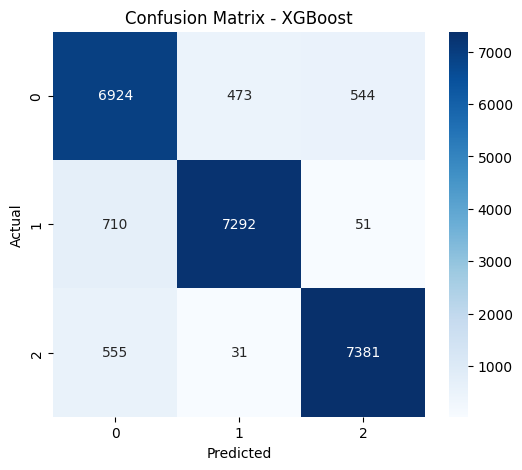

In [48]:
from sklearn.metrics import confusion_matrix

# Use model3 which was trained on the X_train with 12 features after resampling
xgb_model = model3

# Recalculate pred_encoded based on the current X_test
# This ensures consistency with the current y_test_encoded
pred_encoded = xgb_model.predict(X_test)

# Calculate confusion matrix using the encoded target and predictions
cm = confusion_matrix(y_test_encoded, pred_encoded)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

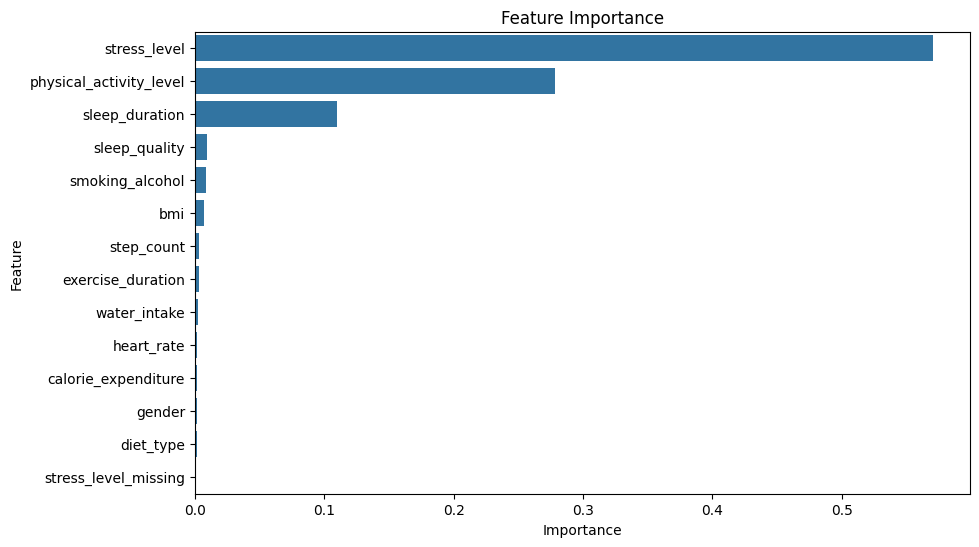

In [40]:
feature_names = df.drop('health_condition', axis=1).columns
importance = pd.DataFrame({'Feature': feature_names, 'Importance': model.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(data=importance,
            x='Importance',
            y='Feature')

plt.title("Feature Importance")
plt.show()

In [45]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# Assuming 'models' and 'le' (LabelEncoder) are available from previous cells
xgb_model = models['XGBoost']

# Encode the full 'y' for cross-validation with xgb_model
# It's important to use the same LabelEncoder 'le' that was fitted on y_train
y_encoded_full = le.transform(y)

scores = cross_val_score(
    estimator=xgb_model,
    X=X,
    y=y_encoded_full, # Use the encoded y
    cv=5,
    scoring="accuracy",
    n_jobs=-1      # Use all CPU cores
)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.89996244 0.90083886 0.90075539 0.89941569 0.90125209]
Mean Accuracy: 0.9004448951861745


In [44]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

X = df[['stress_level', 'physical_activity_level', 'sleep_duration','heart_rate','calorie_expenditure','step_count','exercise_duration','water_intake','diet_type','sleep_quality','smoking_alcohol','gender']]
y = df['health_condition']

# Encode the target variable 'y' into numerical format
le_local = LabelEncoder()
y_encoded = le_local.fit_transform(y)

X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42 # Use the encoded y
)

model3 = XGBClassifier(random_state=42)
model3.fit(X_train, y_train_encoded) # Fit with the encoded y_train

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [50]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(['at-risk', 'healthy', 'unhealthy'])

# User Input
stress_level = int(input("Enter Stress Level (0=Low, 1=Medium, 2=High): "))
physical_activity = int(input("Enter Physical Activity Level (0=Low, 1=Moderate, 2=High): "))
sleep_duration = float(input("Enter Sleep Duration (hours): "))
heart_rate = float(input("Enter Heart Rate (beats per minute): "))
bmi = float(input("Enter BMI: "))
calorie_expenditure = float(input("Enter Calorie Expenditure: "))
step_count = int(input("Enter Step Count: "))
exercise_duration = float(input("Enter Exercise Duration (hours): "))
water_intake = float(input("Enter Water Intake (liters): "))
diet_type = int(input("Enter Diet Type (0=Omnivore, 1=Vegetarian, 2=Non-Vegetarian): "))
sleep_quality = int(input("Enter Sleep Quality (0=Poor, 1=Fair, 2=Good): "))
smoking_alcohol = int(input("Enter Smoking and Alcohol Consumption (0=No, 1=Yes): "))
gender = int(input("Enter Gender (0=Male, 1=Female): "))

# Create a DataFrame with the user input


new_data = [[
    stress_level,
    physical_activity,
    sleep_duration,
    heart_rate,
    calorie_expenditure,
    step_count,
    exercise_duration,
    water_intake,
    diet_type,
    sleep_quality,
    smoking_alcohol,
    gender
]]

# Predict
prediction = model3.predict(new_data)

# If LabelEncoder was used on the target
prediction = label_encoder.inverse_transform(prediction)

print("\nPredicted Health Condition:", prediction[0])

Enter Stress Level (0=Low, 1=Medium, 2=High): 2
Enter Physical Activity Level (0=Low, 1=Moderate, 2=High): 2
Enter Sleep Duration (hours): 3
Enter Heart Rate (beats per minute): 79
Enter BMI: 40
Enter Calorie Expenditure: 20
Enter Step Count: 10
Enter Exercise Duration (hours): 2
Enter Water Intake (liters): 3
Enter Diet Type (0=Omnivore, 1=Vegetarian, 2=Non-Vegetarian): 2
Enter Sleep Quality (0=Poor, 1=Fair, 2=Good): 2
Enter Smoking and Alcohol Consumption (0=No, 1=Yes): 0
Enter Gender (0=Male, 1=Female): 0

Predicted Health Condition: at-risk
